# Unscented Kalman Filter (UKF)

This notebook implements a basic Unscented Kalman Filter using
Van der Merwe's scaled sigma point method.

The example demonstrates state estimation for a nonlinear system.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def sigma_points(x, P, alpha, beta, kappa):
    n = x.shape[0]
    lambda_ = alpha**2 * (n + kappa) - n
    sigma_pts = np.zeros((2*n + 1, n))
    Wm = np.zeros(2*n + 1)
    Wc = np.zeros(2*n + 1)

    sqrt_matrix = np.linalg.cholesky((n + lambda_) * P)

    sigma_pts[0] = x
    Wm[0] = lambda_ / (n + lambda_)
    Wc[0] = lambda_ / (n + lambda_) + (1 - alpha**2 + beta)

    for i in range(n):
        sigma_pts[i+1] = x + sqrt_matrix[:, i]
        sigma_pts[n+i+1] = x - sqrt_matrix[:, i]
        Wm[i+1] = Wc[i+1] = 1 / (2 * (n + lambda_))
        Wm[n+i+1] = Wc[n+i+1] = 1 / (2 * (n + lambda_))

    return sigma_pts, Wm, Wc

In [6]:
class UKF:
    def __init__(self, f, h, Q, R, alpha=1e-3, beta=2, kappa=0):
        self.f = f
        self.h = h
        self.Q = Q
        self.R = R
        self.alpha = alpha
        self.beta = beta
        self.kappa = kappa

    def predict(self, x, P):
        sigma_pts, Wm, Wc = sigma_points(x, P, self.alpha, self.beta, self.kappa)
        n = x.shape[0]

        sigma_pred = np.array([self.f(pt) for pt in sigma_pts])
        x_pred = np.sum(Wm[:, None] * sigma_pred, axis=0)

        P_pred = np.zeros((n, n))
        for i in range(2*n + 1):
            diff = sigma_pred[i] - x_pred
            P_pred += Wc[i] * np.outer(diff, diff)

        P_pred += self.Q
        return x_pred, P_pred

    def update(self, x_pred, P_pred, z):
        sigma_pts, Wm, Wc = sigma_points(x_pred, P_pred, self.alpha, self.beta, self.kappa)
        n = x_pred.shape[0]

        sigma_meas = np.array([self.h(pt) for pt in sigma_pts])
        z_pred = np.sum(Wm[:, None] * sigma_meas, axis=0)

        S = np.zeros((z.shape[0], z.shape[0]))
        Cxz = np.zeros((n, z.shape[0]))

        for i in range(2*n + 1):
            dz = sigma_meas[i] - z_pred
            dx = sigma_pts[i] - x_pred
            S += Wc[i] * np.outer(dz, dz)
            Cxz += Wc[i] * np.outer(dx, dz)

        S += self.R
        K = Cxz @ np.linalg.inv(S)

        x_updated = x_pred + K @ (z - z_pred)
        P_updated = P_pred - K @ S @ K.T

        return x_updated, P_updated

In [4]:
# Example nonlinear system
def f(x):
    dt = 0.1
    return np.array([
        x[0] + dt * x[1],
        x[1]
    ])

def h(x):
    return np.array([np.sin(x[0])])

In [5]:
np.random.seed(42)

Q = np.diag([1e-4, 1e-4])
R = np.diag([1e-2])

ukf = UKF(f, h, Q, R)

x_true = np.array([0.0, 1.0])
x_est = np.array([0.1, 0.5])
P = np.eye(2)

true_states = []
estimates = []
measurements = []

for _ in range(100):
    x_true = f(x_true) + np.random.multivariate_normal([0,0], Q)
    z = h(x_true) + np.random.multivariate_normal([0], R)

    x_pred, P_pred = ukf.predict(x_est, P)
    x_est, P = ukf.update(x_pred, P_pred, z)

    true_states.append(x_true.copy())
    estimates.append(x_est.copy())
    measurements.append(z.copy())

true_states = np.array(true_states)
estimates = np.array(estimates)
measurements = np.array(measurements)

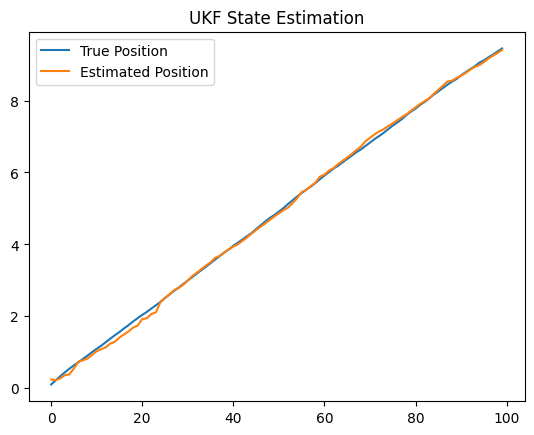

In [6]:
plt.figure()
plt.plot(true_states[:,0], label='True Position')
plt.plot(estimates[:,0], label='Estimated Position')
plt.legend()
plt.title('UKF State Estimation')
plt.show()

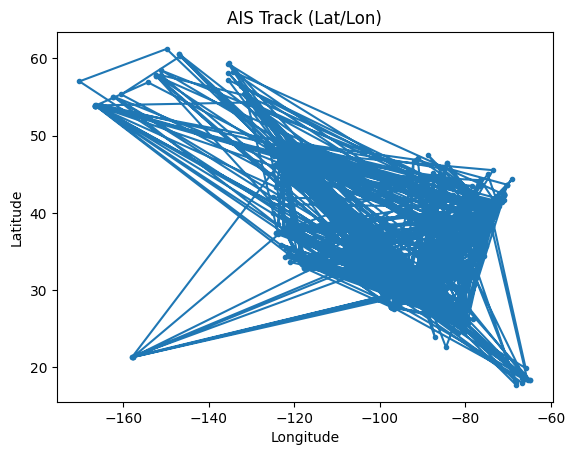

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load AIS CSV
df = pd.read_csv("Data/AIS_2016_11_22.csv")

# Convert timestamps
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

# Sort chronologically
df = df.sort_values("BaseDateTime").reset_index(drop=True)

# ---- Limit dataset to first 1000 points ----
df = df.iloc[:1000]

# Extract coordinates (lat/lon directly)
lat = df["LAT"].values
lon = df["LON"].values

positions = np.column_stack((lat, lon))


# ---- Compute dt from timestamps ----
times = df["BaseDateTime"].astype("int64") // 10**9
times = times.to_numpy()

dt = np.diff(times, prepend=times[0])

In [7]:
# Initial state [lat, v_lat, lon, v_lon]
x = np.array([
    positions[0,0],
    0.0,
    positions[0,1],
    0.0
])

P = np.eye(4) * 10

Q = np.eye(4) * 0.1
R = np.eye(2) * 1e-8

n = 4

alpha = 1e-3
beta = 2
kappa = 0

ukf_estimates = []

innovations = []
nis_values = []

for k in range(len(positions)):

    dt_k = dt[k]

    sigma, lambda_ = sigma_points(x, P, alpha, beta, kappa)

    Wm = np.full(2*n+1, 1/(2*(n+lambda_)))
    Wc = np.full(2*n+1, 1/(2*(n+lambda_)))

    Wm[0] = lambda_/(n+lambda_)
    Wc[0] = lambda_/(n+lambda_) + (1-alpha**2+beta)

    # Propagate sigma points
    sigma_pred = []

    for s in sigma:

        lat, vlat, lon, vlon = s

        sigma_pred.append([
            lat + vlat * dt_k,
            vlat,
            lon + vlon * dt_k,
            vlon
        ])

    sigma_pred = np.array(sigma_pred)

    x_pred = np.sum(Wm[:,None] * sigma_pred, axis=0)

    P_pred = Q.copy()

    for i in range(2*n+1):

        diff = sigma_pred[i] - x_pred
        P_pred += Wc[i] * np.outer(diff, diff)

    # Measurement prediction
    Z = sigma_pred[:,[0,2]]

    z_pred = np.sum(Wm[:,None] * Z, axis=0)

    S = R.copy()

    for i in range(2*n+1):

        diff = Z[i] - z_pred
        S += Wc[i] * np.outer(diff, diff)

    # Cross covariance
    Pxz = np.zeros((n,2))

    for i in range(2*n+1):

        dx = sigma_pred[i] - x_pred
        dz = Z[i] - z_pred

        Pxz += Wc[i] * np.outer(dx, dz)

    K = Pxz @ np.linalg.inv(S)

    z = positions[k]

    y = z - z_pred

    x = x_pred + K @ y
    P = P_pred - K @ S @ K.T

    ukf_estimates.append([x[0], x[2]])

    innovations.append(y)

    nis = y.T @ np.linalg.inv(S) @ y
    nis_values.append(nis)


ukf_estimates = np.array(ukf_estimates)

ukf_innovations = np.array(innovations)
ukf_nis = np.array(nis_values)

ValueError: too many values to unpack (expected 2)

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(np.linalg.norm(ukf_innovations, axis=1))

plt.title("UKF Innovation Magnitude (AIS Data)")
plt.xlabel("Time Step")
plt.ylabel("Innovation Norm")

plt.show()